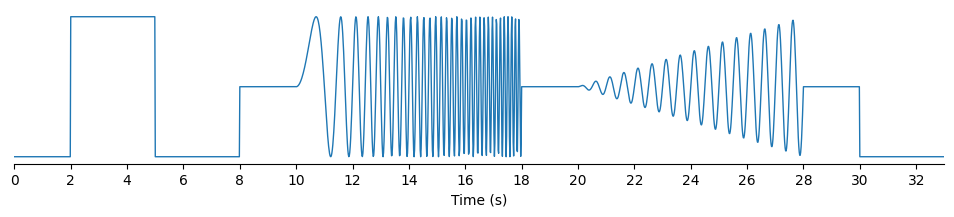

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dt = 1/60
IHalf = 127
IFull = 254
chirpDur = 8
ContrastFreq = 2
K = 8 / chirpDur

time = []
intensity = []

current_time = 0

def add_segment(duration, value):
    global current_time
    n = int(duration / dt)
    t = current_time + np.arange(n) * dt
    time.extend(t)
    intensity.extend(np.full(n, value))
    current_time += duration



add_segment(2, 0)
add_segment(3, 254)
add_segment(3, 0)
add_segment(2, 127)
t = np.arange(0, chirpDur, dt)
I = np.sin(np.pi * K * t**2) * IHalf + IHalf

time.extend(current_time + t)
intensity.extend(I)

current_time += chirpDur
add_segment(2, 127)
t = np.arange(0, chirpDur, dt)
IRamp = IHalf * t / chirpDur
I = np.sin(2 * np.pi * ContrastFreq * t) * IRamp + IHalf

time.extend(current_time + t)
intensity.extend(I)

current_time += chirpDur
add_segment(2, 127)
add_segment(3, 0)

plt.subplots(figsize=(12, 2))
plt.plot(time, intensity, linewidth=1)
sns.despine(left=True)
plt.yticks([])
plt.xlim(0,33)
plt.xticks(np.arange(0,34,2))
plt.xlabel("Time (s)")
plt.show()